In [163]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    # '250917_zero_shot_cl',
    # '250905-multimutant-benchmark',
    '250905-test-benchmark',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'MTHR_HUMAN_Weile_2021', 'RNC_ECOLI_Weeks_2023', 'MLAC_ECOLI_MacRae_2023', 'AMIE_PSEAE_Wrenbeck_2017', 'LGK_LIPST_Klesmith_2015', 'S22A1_HUMAN_Yee_2023_activity', 'A4GRB6_PSEAI_Chen_2020', 'KCNJ2_MOUSE_Coyote-Maestas_2022_function', 'PPARG_HUMAN_Majithia_2016', 'KKA2_KLEPN_Melnikov_2014', 'PAI1_HUMAN_Huttinger_2021', 'MSH2_HUMAN_Jia_2020', 'PTEN_HUMAN_Mighell_2018', 'SC6A4_HUMAN_Young_2021', 'MET_HUMAN_Estevam_2023', 'CAS9_STRP1_Spencer_2017_positive', 'HMDH_HUMAN_Jiang_2019'}


In [164]:
round_metrics_df.config_name.value_counts()

config_name
FolDE-no-constantliar-ucb                     1020
FolDE-with-esmv1-zsclS4                       1020
Random                                        1020
FolDE-base                                    1020
FolDE-with-esmv1-nocl-nowarmstart             1020
RandomToRandomForest-300m-embeddings          1020
RandomToRandomForest-base                     1020
FolDE-no-constantliar                         1020
FolDE-no-naturalnessTraining-or-ensemble      1020
FolDE-clS1                                    1020
FolDE-with-esmv1-zsclS4-r1only                1020
FolDE-no-MLP                                  1020
FolDE-with-esmv1-nocl                         1020
FolDE-no-ensemble                             1020
FolDE-no-naturalnessTraining                  1020
FolDE-constantliar-ucb                        1020
FolDE-with-esmv1-zsclS4-r1only-nowarmstart    1020
FolDE-no-BTLoss                               1020
FolDE-with-esmv1                              1020
FolDE-no-zeroShot  

In [165]:
round_metrics_df.columns

Index(['dms_id', 'config_name', 'sim_num', 'variant_pool_size',
       'best_activity_this_round', 'best_percentile_this_round',
       'best_activity_so_far', 'normalized_best_activity_so_far',
       'best_percentile_so_far', 'round_num', 'model_spearman', 'misc',
       'held_out_activity_spearman', 'held_out_1pct_recall',
       'held_out_1pct_recall_slate', 'held_out_1pct_auc',
       'held_out_10pct_recall', 'held_out_10pct_recall_slate',
       'held_out_10pct_auc', 'zero_shot_debug_info', 'few_shot_debug_info',
       'held_out_batch_1pct', 'held_out_batch_10pct', 'dms_shortname'],
      dtype='object')

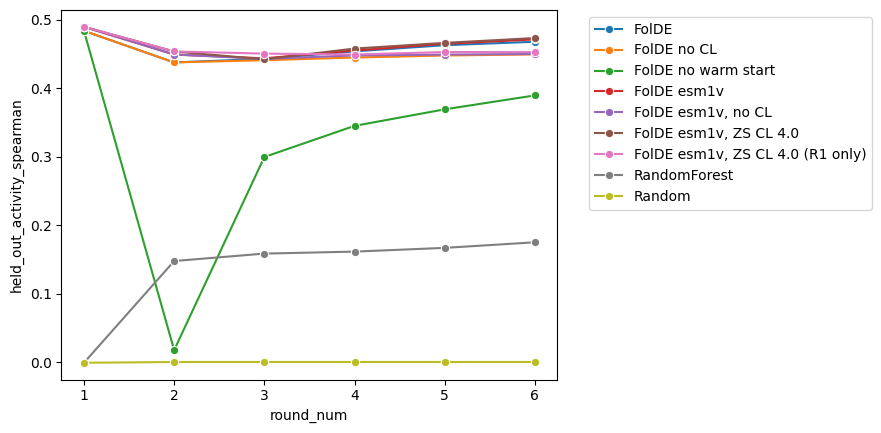

In [166]:
round_metrics_df['enrichment'] = (round_metrics_df.held_out_1pct_recall / 0.01 + round_metrics_df.held_out_10pct_recall / 0.10) / 2.0
round_metrics_df['enrichment_slate'] = (round_metrics_df.held_out_1pct_recall_slate / 0.01 + round_metrics_df.held_out_10pct_recall_slate / 0.10) / 2.0
round_metrics_df['batch_enrichment'] = (round_metrics_df.held_out_batch_1pct / 0.01 + round_metrics_df.held_out_batch_10pct / 0.10) / 2.0


# # To compare FolDE with and without components:
# CONFIG_RENAMES = {
#     'FolDE-with-esmv1-zsclS1-r1only': 'New FolDE (ZS CL 1.0, R1 only)',
#     # 'FolDE-with-esmv1-zsclS1-ucb': 'New FolDE + UCB',
#     # 'FolDE-with-esmv1': 'New FolDE - ZS CL + FS CL',
#     'FolDE-with-esmv1-no-constantliar': 'New FolDE, no CL (ever)',
#     # 'FolDE-with-esmv1-no-warmstart-zsclS025': 'New FolDE, no warm start',
#     # 'FolDE-with-esmv1-no-constantliar-or-warm-start': 'New FolDE, no CL or warm start',
#     'RandomToRandomForest-with-esmv1-zeroshot': 'RandomForest + ZS',
#     'RandomToRandomForest-base': 'RandomForest',
#     'Random': 'Random',
# }

# # To find the best CL settings for FolDE:
# CONFIG_RENAMES = {
#     'FolDE-with-esmv1': 'FolDE no ZS CL',
#     'FolDE-with-esmv1-zsclS4': 'FolDE ZS CL 4.0',
#     'FolDE-with-esmv1-zsclS4-r1only': 'FolDE ZS CL 4.0 (R1 only)',
#     'FolDE-with-esmv1-zsclS1': 'FolDE ZS CL 1.0',
#     'FolDE-with-esmv1-zsclS1-r1only': 'FolDE ZS CL 1.0 (R1 only)',
#     'FolDE-with-esmv1-zsclS025': 'FolDE ZS CL 0.25',
#     # 'FolDE-with-esmv1-zsclS025-r1only': 'FolDE ZS CL 0.25 (R1 only)',
#     'FolDE-with-esmv1-zsclS01': 'FolDE ZS CL 0.1',
#     'RandomToRandomForest-base': 'RandomForest',
#     'Random': 'Random',
# }

# Multimutant & Test Benchmarks
CONFIG_RENAMES = {
    'FolDE-base': 'FolDE',
    'FolDE-no-constantliar': 'FolDE no CL',
    'FolDE-no-naturalnessTraining': 'FolDE no warm start',
    # 'FolDE-no-zeroShot': 'Old FolDE no zero shot',
    'FolDE-with-esmv1': 'FolDE esm1v',
    # 'FolDE-with-esmv1-nocl-nowarmstart': 'New FolDE, no CL or warm start',
    # 'FolDE-with-esmv1-zsclS4-r1only-nowarmstart': 'New FolDE, no warm start',
    'FolDE-with-esmv1-nocl': 'FolDE esm1v, no CL',
    'FolDE-with-esmv1-zsclS4': 'FolDE esm1v, ZS CL 4.0',
    'FolDE-with-esmv1-zsclS4-r1only': 'FolDE esm1v, ZS CL 4.0 (R1 only)',
    'RandomToRandomForest-base': 'RandomForest',
    'Random': 'Random',
}
plot_df = round_metrics_df[round_metrics_df.config_name.isin(CONFIG_RENAMES.keys())].reset_index()
plot_df['config_name'] = plot_df.config_name.map(CONFIG_RENAMES)
plot_df['inverse_best_percentile_so_far'] = 1 - plot_df['best_percentile_so_far']

for k, v in CONFIG_RENAMES.items():
    assert v in plot_df.config_name.unique(), f'{v} not found, only {plot_df.config_name.unique()}'

plt.figure()
ax = sns.lineplot(
    data=plot_df,#[plot_df.dms_id != 'ANCSZ_Hobbs_2022'].reset_index(),
    y='held_out_activity_spearman',
    x='round_num',
    hue='config_name',
    errorbar=None,
    marker='o',
    hue_order=list(CONFIG_RENAMES.values()),
)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


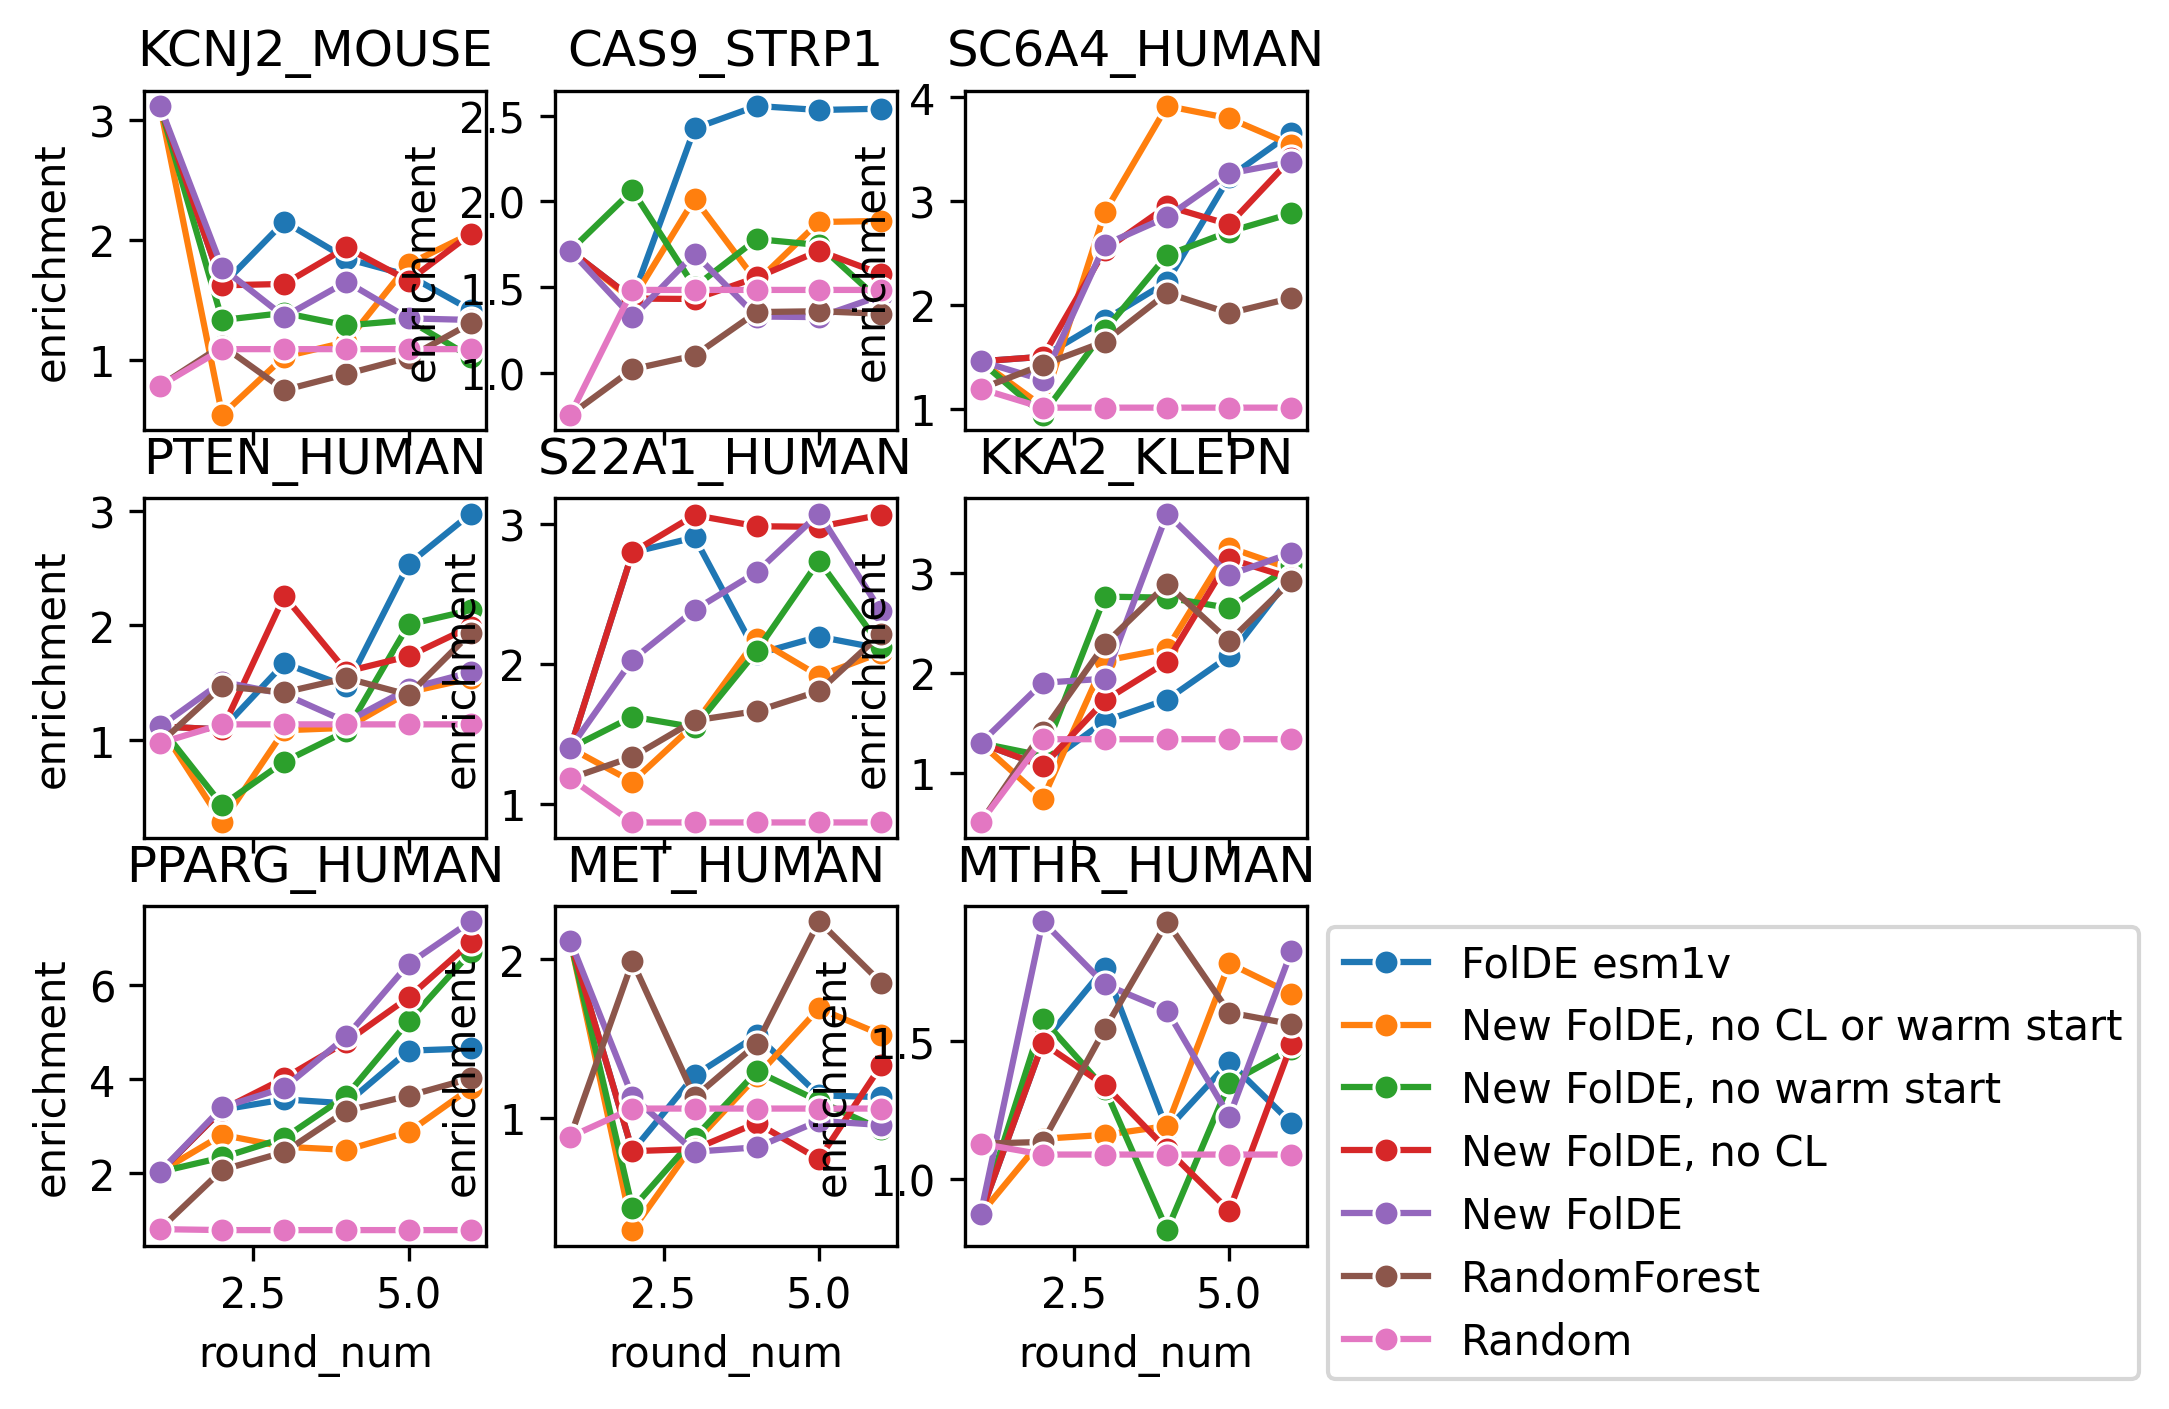

In [110]:

fig, axes = plt.subplots(3, 3, figsize=(5, 5), dpi=300, sharex=True, sharey=False)

dmss = round_metrics_df.dms_id.unique()
for ii, ax in enumerate(axes.flatten()):
    dms_id = dmss[ii]
    sns.lineplot(
        ax=ax,
        data=plot_df[plot_df.dms_id == dms_id].reset_index(),
        # y='held_out_activity_spearman',
        # y='enrichment',
        y='enrichment',
        # y='held_out_activity_spearman',
        x='round_num',
        hue='config_name',
        errorbar=None,
        marker='o',
        hue_order=list(CONFIG_RENAMES.values()),
        # style='config_name',
        # errorbar=None
    )
    if ii == 8:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    else:
        ax.legend_.remove()
    ax.set_title(DMS_SHORTNAMES[dms_id])

In [142]:
from folde.data import get_proteingym_dataset

wt_aa_seq, naturalness_df, embedding_df, activity_df, category_df = get_proteingym_dataset('HXK4_HUMAN_Gersing_2022_activity', '300m', '1v')

naturalness_df

model,wt_marginal_1,wt_marginal_2,wt_marginal_3,wt_marginal_4,wt_marginal_5
M1A,0.012130,0.014995,0.001512,0.005485,0.016843
M1C,0.004207,0.004279,0.000646,0.002587,0.003873
M1D,0.005083,0.005478,0.001812,0.003380,0.005404
M1E,0.006235,0.009174,0.001813,0.004031,0.006745
M1F,0.007715,0.004474,0.001321,0.002956,0.007437
...,...,...,...,...,...
Q465S,0.106069,0.001278,0.048123,0.064880,0.054289
Q465T,0.031045,0.000628,0.018971,0.025743,0.042252
Q465V,0.020888,0.003929,0.015402,0.016935,0.019264
Q465W,0.001727,0.000228,0.000398,0.000713,0.000355


In [98]:
from Bio import pairwise2

# pairwise2.align.globalxx('ABC' * 300, 'GBC' * 300)
import Levenshtein


300

In [100]:
%%timeit
Levenshtein.distance('ABC' * 300, 'GBC' * 300)

33.4 μs ± 260 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [102]:
(100000*40*8 * 30 / 1e6) /60

16.0

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_66567/392223823.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['inverse_best_percentile_so_far'] = 1 - plot_df['best_percentile_so_far']
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_66567/392223823.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['config_name'] = plot_df.config_name.map(CONFIG_RENAMES)


<Axes: xlabel='round_num', ylabel='inverse_best_percentile_so_far'>

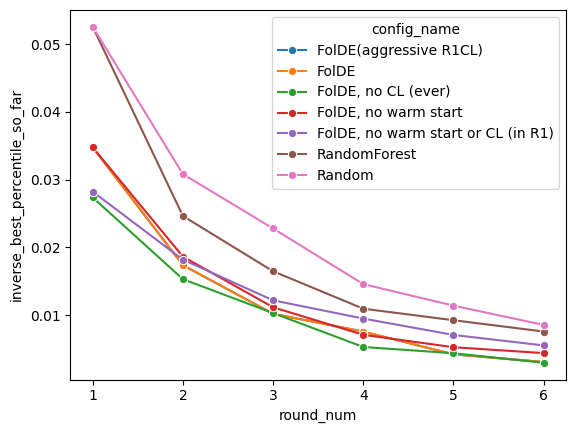

In [51]:
round_metrics_df['enrichment'] = (round_metrics_df.held_out_1pct_recall_slate / 0.01 + round_metrics_df.held_out_10pct_recall_slate / 0.10) / 2.0

CONFIG_RENAMES = {
    'FolDE-with-esmv1-zsclS01': 'FolDE(aggressive R1CL)',
    'FolDE-with-esmv1-zsclS025': 'FolDE',
    'FolDE-with-esmv1-no-constantliar': 'FolDE, no CL (ever)',
    'FolDE-no-warmstart-with-esmv1-zsclS025': 'FolDE, no warm start',
    'FolDE-no-warmstart': 'FolDE, no warm start or CL (in R1)',
    'RandomToRandomForest': 'RandomForest',
    'Random': 'Random',
}
# CONFIG_RENAMES = {
#     'FolDE-with-esmv1-zsclS025': 'FolDE',
#     'RandomToRandomForest': 'RandomForest',
#     'RandomToRandomForest-with-esmv1-zeroshot': 'RF with zero-shot',
#     'RandomToRandomForest-with-esmv1-zeroshot-clS025': 'RF with zero-shot and CL',
#     'Random': 'Random',
# }
plot_df = round_metrics_df[round_metrics_df.config_name.isin(CONFIG_RENAMES.keys())]
plot_df['inverse_best_percentile_so_far'] = 1 - plot_df['best_percentile_so_far']

plot_df['config_name'] = plot_df.config_name.map(CONFIG_RENAMES)

sns.lineplot(
    data=plot_df,
    # y='held_out_activity_spearman',
    y='inverse_best_percentile_so_far',
    # y='held_out_1pct_auc',
    # y='held_out_activity_spearman',
    x='round_num',
    hue='config_name',
    errorbar=None,
    marker='o',
    hue_order=list(CONFIG_RENAMES.values()),
    # style='config_name',
    # errorbar=None
)

In [34]:
round_metrics_df.best_percentile_this_round.describe()

count    7020.000000
mean        1.061359
std         0.914607
min        -0.170661
25%         0.384294
50%         1.077712
75%         1.414341
max         6.670528
Name: best_percentile_this_round, dtype: float64

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_66567/2976080449.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['inverse_best_percentile_so_far'] = 1 - plot_df['best_percentile_so_far']
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_66567/2976080449.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=12, ha="right")


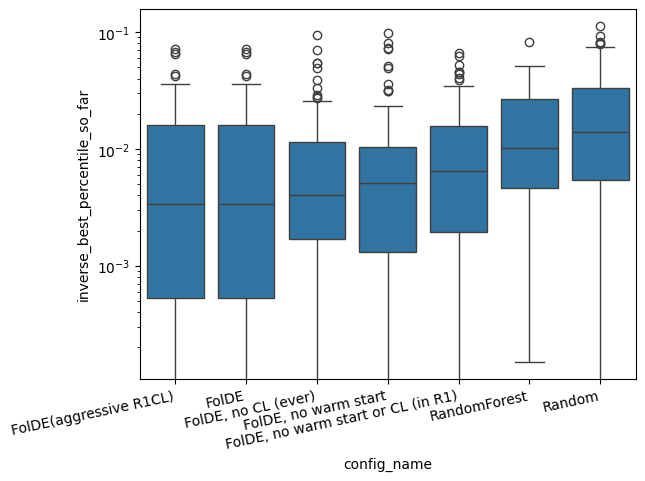

In [47]:
ax = sns.boxplot(
    data=plot_df[plot_df.round_num == 3].reset_index(),
    x='config_name',
    y='inverse_best_percentile_so_far',
    order=list(CONFIG_RENAMES.values()),
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=12, ha="right")
ax.set_yscale('log')

Text(0.5, 0, '')

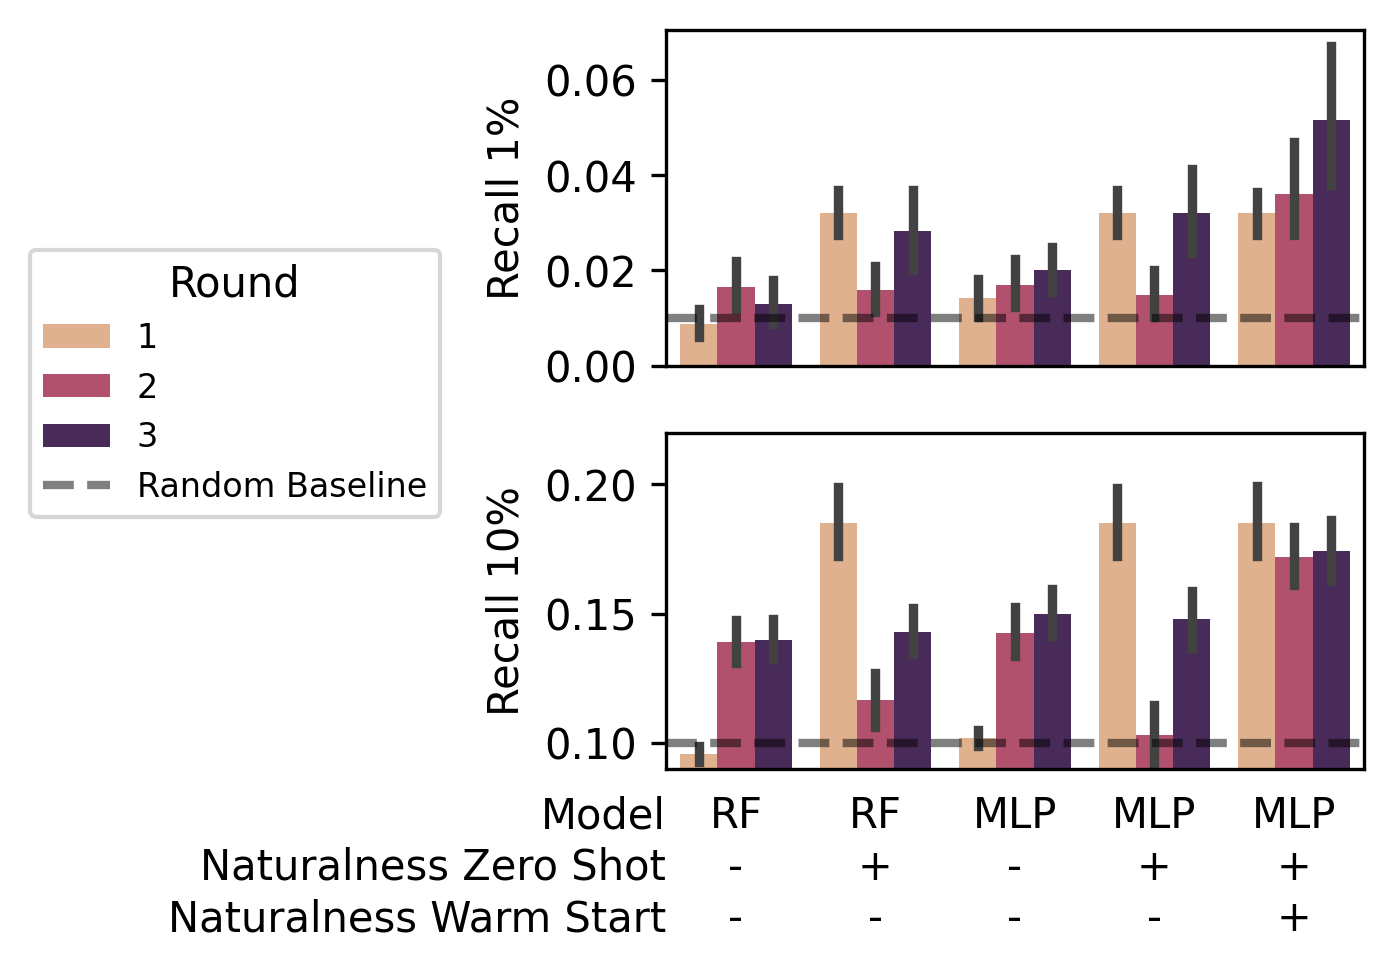

In [4]:
configs = [
    ('RandomForest-base', 'RandomForest + Random First Round'),
    ('RandomForest-naturalnessZeroShot', 'RandomForest + Naturalness First Round'),
    ('MLP-randomZeroShot', 'MLP + Random First Round'),
    ('MLP-naturalnessZeroShot', 'MLP + Naturalness First Round'),
    ('MLP-naturalnessZeroShot-natTraining', 'MLP + Naturalness First Round +\nTraining'),
    # ('MLP-randomZeroShot-natTraining', 'Random First Round +\nTraining'),
]

plot_df = round_metrics_df.copy()
plot_df['config_name'] = plot_df['config_name'].apply(lambda x: dict(configs).get(x, x))
plot_df['Round'] = plot_df['round_num']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 3.2), sharex=True, dpi=300)

for ax, metric in zip([ax1, ax2], [ 'held_out_1pct_recall', 'held_out_10pct_recall']):
    sns.barplot(
        ax=ax,
        data=plot_df[(plot_df.round_num <= 3) & (plot_df.config_name.isin([c for _, c in configs]))],
        x='config_name',
        y=metric,
        hue='Round',
        order=[c for _, c in configs],
        palette='flare'
    )

treatment_matrix = [
    ['RF', 'RF', 'MLP', 'MLP', 'MLP'],
    ['-', '+', '-', '+', '+'],
    ['-', '-', '-', '-', '+'],
]

row_labels = ['Model', 'Naturalness Zero Shot', 'Naturalness Warm Start']
for i, label in enumerate(row_labels):
    y = 0.08 - i * 0.02  # control vertical spacing
    for j, sym in enumerate(treatment_matrix[i]):
        ax2.text(j, y, sym, ha='center', va='top', fontsize=10)
    # Optional: add row label on the left
    ax2.text(-0.5, y, label, ha='right', va='top', fontsize=10)

# Clean up plot
# ax1.set_ylim(0.09, 0.22)
ax1.set_ylabel('Recall 1%')
ax1.axhline(y=0.01, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')


ax2.set_ylim(0.09, 0.22)
ax2.set_ylabel('Recall 10%')
# ax.spines['bottom'].set_visible(False)
ax2.tick_params(axis='x', length=0)
ax2.set_xticks([])  # hide original x-axis labels if desired
ax2.axhline(y=0.1, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')


ax1.legend(
    title='Round',
    loc='lower right',
    bbox_to_anchor=(-0.3, -0.5),
    fontsize=8,

)
ax2.get_legend().remove()

ax1.set_xlabel('')

ax2.set_xlabel('')

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_87876/2356851255.py:49: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_87876/2356851255.py:49: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_87876/2356851255.py:73: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_87876/2356851255.py:73: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_87876/2356851255.

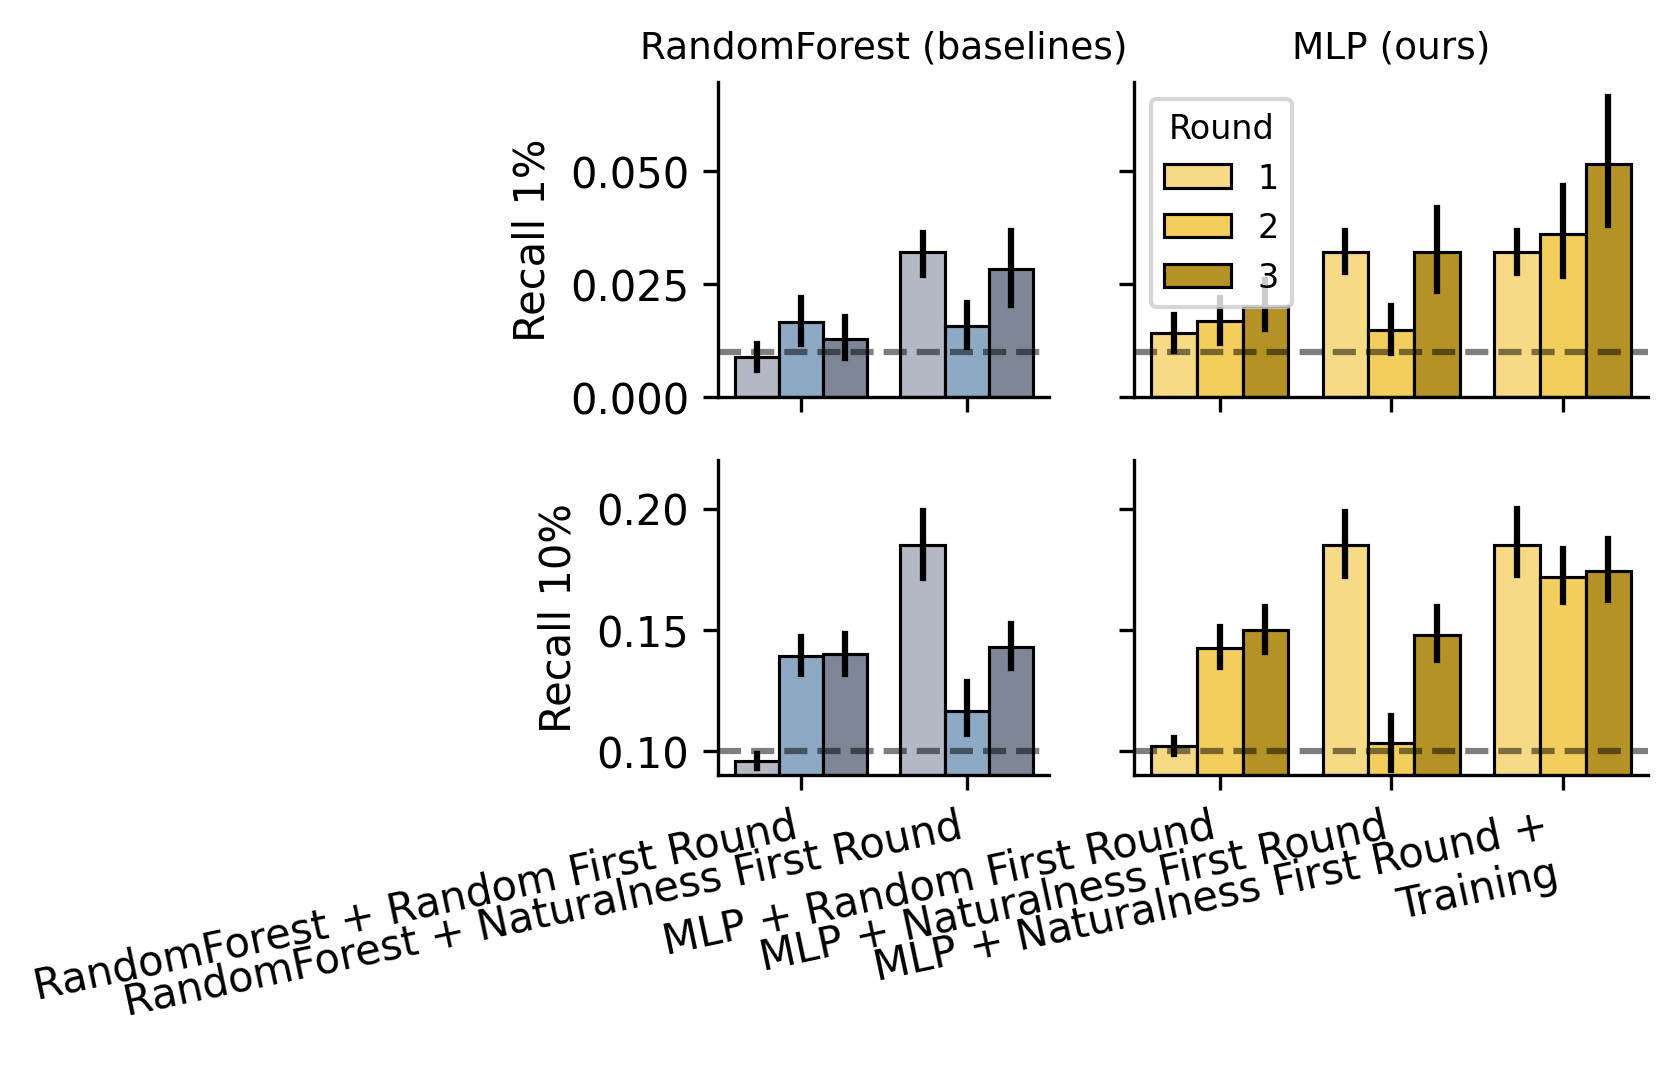

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt


# Teal: 2A9D8F
# Pretty light gold: FFE5B4
# Rust / amber: B86F2A
# Plum: 5B4E77

# === Palettes (hex doubles as your Illustrator swatches) ===
# RF family (bluish / neutralish): Round 1 → lightest, Round 3 → darkest
rf_round_palette = {1: "#B4B8C5", 2: "#8DA9C4", 3: "#7D8597"}

# MLP family (orangish): Round 1 → lightest, Round 3 → most saturated
mlp_round_palette = {       1: "#f7da85",  # light/mid orange
    2: "#f4ce5c",  # medium orange
    3: "#b59226",  # deeper orange (not too dark)

}

# Optional deeper accent if you need to highlight “+ Training” in callouts elsewhere
mlp_deep_accent = "#9D0208"

# --- Prepare data & labels ---
config_map = dict(configs)
plot_df = round_metrics_df.copy()
plot_df["config_name"] = plot_df["config_name"].apply(lambda x: config_map.get(x, x))
plot_df["Round"] = plot_df["round_num"]

# Column orders per family
rf_order  = [label for key, label in configs if key.startswith("RandomForest-")]
mlp_order = [label for key, label in configs if key.startswith("MLP-")]

# --- Figure layout: 2 rows (metrics) × 2 cols (RF | MLP); scaled widths ---
fig, axs = plt.subplots(
    nrows=2, ncols=2, figsize=(4, 3), dpi=300,
    sharey="row", gridspec_kw={"width_ratios": [0.9, 1.4]}
)

metrics = [("held_out_1pct_recall", 0.01, "Recall 1%"),
           ("held_out_10pct_recall", 0.10, "Recall 10%")]

hue_order = [1, 2, 3]  # rounds

for row, (metric, baseline, ylabel) in enumerate(metrics):
    # --- Left: RF ---
    axL = axs[row, 0]
    rf_data = plot_df[(plot_df.round_num <= 3) & (plot_df["config_name"].isin(rf_order))]
    sns.barplot(
        ax=axL, data=rf_data, x="config_name", y=metric,
        hue="Round", hue_order=hue_order, order=rf_order,
        palette=rf_round_palette,
        saturation=1.0,
        edgecolor='black', linewidth=0.75, errcolor='black', errwidth=1.5
    )
    axL.axhline(baseline, color="black", linewidth=1.5, alpha=0.5, linestyle="--")
    axL.set_ylabel(ylabel if row == 0 else ylabel)  # keep both visible
    if row == 0:
        axL.set_title("RandomForest (baselines)", fontsize=9)
    axL.set_xlabel("")
    # top row: hide x tick labels to reduce clutter
    if row == 0:
        axL.set_xticklabels([])
    else:
        axL.set_xticklabels(axL.get_xticklabels(), rotation=12, ha="right")

    # Remove duplicate legends; keep only top-right later
    axL.legend_.remove()

    # --- Right: MLP ---
    axR = axs[row, 1]
    mlp_data = plot_df[(plot_df.round_num <= 3) & (plot_df["config_name"].isin(mlp_order))]
    sns.barplot(
        ax=axR, data=mlp_data, x="config_name", y=metric,
        hue="Round", hue_order=hue_order, order=mlp_order,
        palette=mlp_round_palette,
        saturation=1.0,
        edgecolor='black', linewidth=0.75, errcolor='black', errwidth=1.5
    )
    axR.axhline(baseline, color="black", linewidth=1.5, alpha=0.5, linestyle="--")
    if row == 0:
        axR.set_title("MLP (ours)", fontsize=9)
    axR.set_xlabel("")
    if row == 0:
        axR.set_xticklabels([])
    else:
        axR.set_xticklabels(axR.get_xticklabels(), rotation=12, ha="right")

    # Keep legend only on the top-right panel
    if row == 1:
        axR.legend_.remove()

# Put a single legend for Rounds on the top-right axis
handles, labels = axs[0, 1].get_legend_handles_labels()
axs[0, 1].legend(handles, labels, title="Round", fontsize=8, title_fontsize=8, loc="upper left")

# Optional: match your previous y-limits for the second row
axs[1, 0].set_ylim(0.09, 0.22)
axs[1, 1].set_ylim(0.09, 0.22)

sns.despine(fig)
fig.tight_layout()
fig.savefig('notebooks/jacob/paperplots/fig3_r1_tension.svg', bbox_inches='tight', transparent=True)

In [40]:
plot_df.groupby(['config_name', 'round_num']).held_out_10pct_recall.mean()

config_name                                   round_num
MLP + Naturalness First Round                 1            0.185041
                                              2            0.103183
                                              3            0.147865
MLP + Naturalness First Round +\nTraining     1            0.185041
                                              2            0.171937
                                              3            0.174406
MLP + Random First Round                      1            0.101985
                                              2            0.142584
                                              3            0.149871
MLP-naturalnessZeroShot-ensemble              1            0.185041
                                              2            0.103258
                                              3            0.150414
MLP-naturalnessZeroShot-natTraining-ensemble  1            0.185041
                                              2            0

In [43]:
(0.142584 - 0.103183) / 0.142584

0.2763353531953094